#Predcition of CO2 emission in different vehicles using machine learning

##Problem Statement

###1. Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.
###2. Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.
###3. Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions

##Familiarizing with the data set

###Dataset Link

#### https://raw.githubusercontent.com/KarthiObli/CO2EmissionMachineLearning/refs/heads/main/CO2_Emissions_Dataset.csv

### Feature study

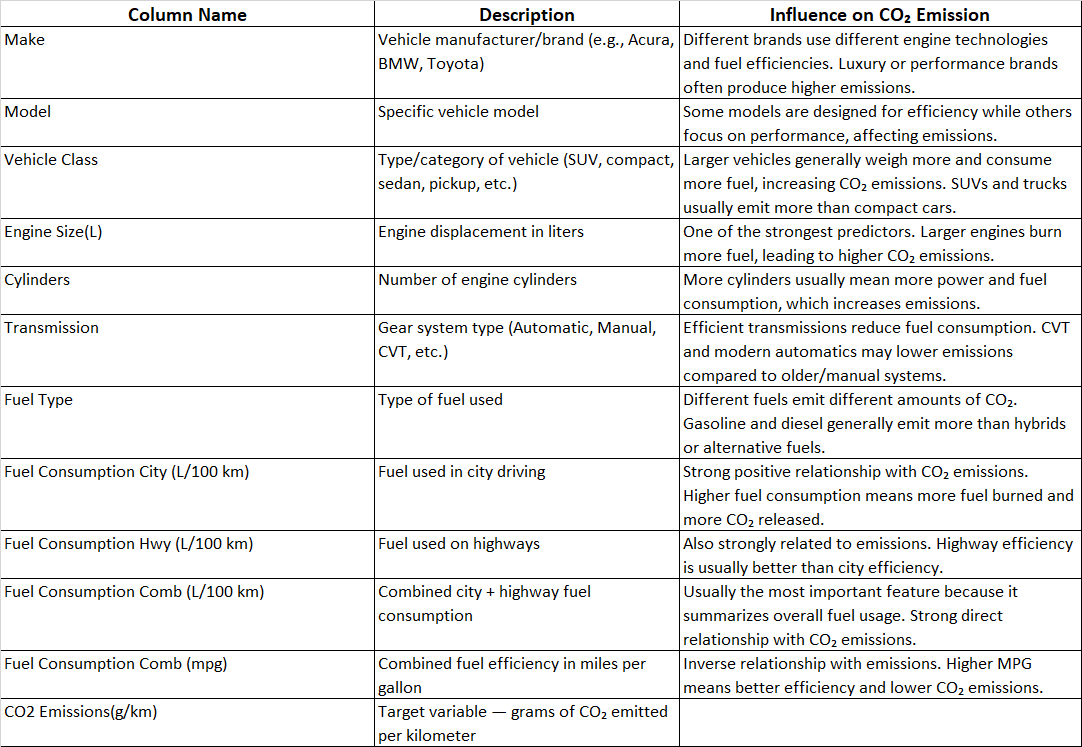

##Data Preprocessing

###import

In [218]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score

###Dataframe

In [219]:
df = pd.read_csv('https://raw.githubusercontent.com/KarthiObli/CO2EmissionMachineLearning/refs/heads/main/CO2_Emissions_Dataset.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

### Duplicate Handling

In [221]:
df.duplicated().sum()

np.int64(1103)

In [222]:
df.drop_duplicates(inplace=True)

1103 duplicate rows were identified and removed

###Test Train Split

In [223]:
x=df.drop('CO2 Emissions(g/km)',axis=1)
y=df['CO2 Emissions(g/km)']

In [224]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=5)

In [225]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5025, 11)
(1257, 11)
(5025,)
(1257,)


###Missing data handling

In [226]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5025 entries, 77 to 3124
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              5025 non-null   object 
 1   Model                             5025 non-null   object 
 2   Vehicle Class                     5025 non-null   object 
 3   Engine Size(L)                    5025 non-null   float64
 4   Cylinders                         5025 non-null   int64  
 5   Transmission                      5025 non-null   object 
 6   Fuel Type                         5025 non-null   object 
 7   Fuel Consumption City (L/100 km)  5025 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   5025 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  5025 non-null   float64
 10  Fuel Consumption Comb (mpg)       5025 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 471.1+ KB


In [227]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 5025 entries, 77 to 3124
Series name: CO2 Emissions(g/km)
Non-Null Count  Dtype
--------------  -----
5025 non-null   int64
dtypes: int64(1)
memory usage: 78.5 KB


No missing data identified, Missing data handling is not required

###Outlier handling

In [228]:
def upper_limit_xtrain(feature):
  Q1 = x_train[feature].quantile(0.25)
  Q3 = x_train[feature].quantile(0.75)
  IQR = Q3 - Q1
  Upper_Limit = Q3 + 1.5*IQR
  return Upper_Limit

def lower_limit_xtrain(feature):
  Q1 = x_train[feature].quantile(0.25)
  Q3 = x_train[feature].quantile(0.75)
  IQR = Q3 - Q1
  Lower_Limit = Q1 - 1.5*IQR
  return Lower_Limit

In [229]:
def upper_limit_ytrain():
  Q1 = y_train.quantile(0.25)
  Q3 = y_train.quantile(0.75)
  IQR = Q3 - Q1
  Upper_Limit = Q3 + 1.5*IQR
  return Upper_Limit

def lower_limit_ytrain():
  Q1 = y_train.quantile(0.25)
  Q3 = y_train.quantile(0.75)
  IQR = Q3 - Q1
  Lower_Limit = Q1 - 1.5*IQR
  return Lower_Limit

<Axes: xlabel='Fuel Consumption City (L/100 km)'>

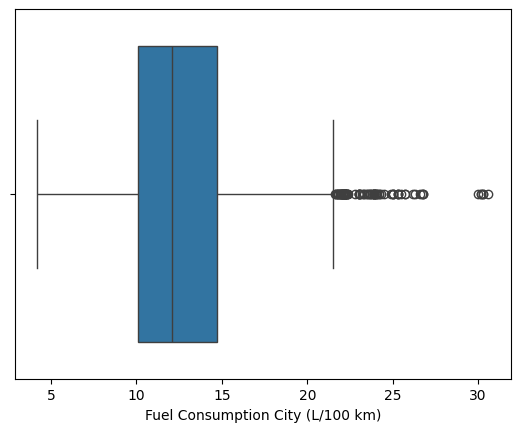

In [230]:
sns.boxplot(x=x_train['Fuel Consumption City (L/100 km)'])

In [231]:
mask = (x_train['Fuel Consumption City (L/100 km)'] < upper_limit_xtrain('Fuel Consumption City (L/100 km)')) & (x_train['Fuel Consumption City (L/100 km)'] > lower_limit_xtrain('Fuel Consumption City (L/100 km)'))

In [232]:
x_train = x_train[mask]
y_train = y_train[mask]

<Axes: xlabel='Fuel Consumption City (L/100 km)'>

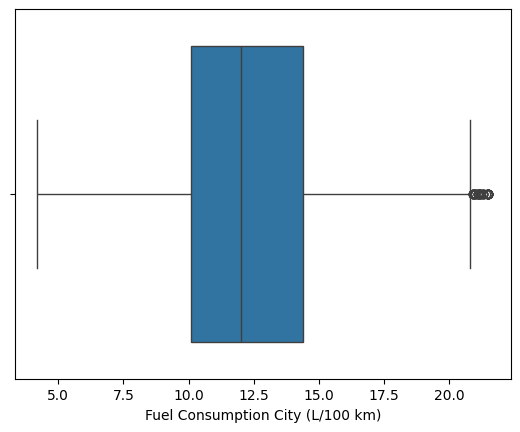

In [233]:
sns.boxplot(x=x_train['Fuel Consumption City (L/100 km)'])

<Axes: xlabel='Fuel Consumption Hwy (L/100 km)'>

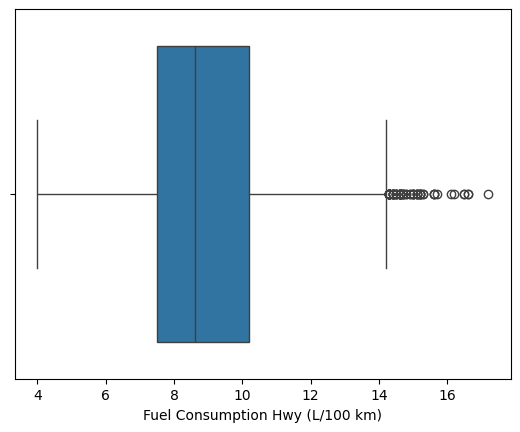

In [234]:
sns.boxplot(x=x_train['Fuel Consumption Hwy (L/100 km)'])

In [235]:
mask = (x_train['Fuel Consumption Hwy (L/100 km)'] < upper_limit_xtrain('Fuel Consumption Hwy (L/100 km)')) & (x_train['Fuel Consumption Hwy (L/100 km)'] > lower_limit_xtrain('Fuel Consumption Hwy (L/100 km)'))

In [236]:
x_train = x_train[mask]
y_train = y_train[mask]

<Axes: xlabel='Fuel Consumption Hwy (L/100 km)'>

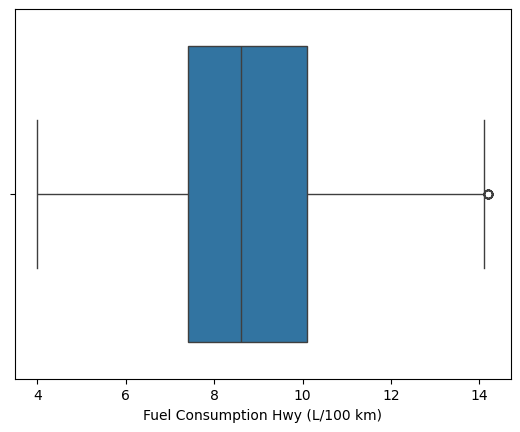

In [237]:
sns.boxplot(x=x_train['Fuel Consumption Hwy (L/100 km)'])

<Axes: xlabel='Fuel Consumption Comb (L/100 km)'>

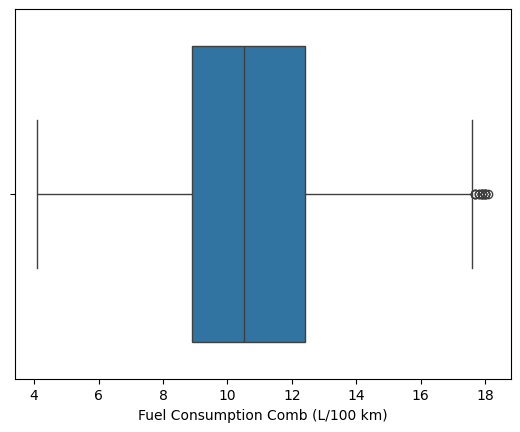

In [238]:
sns.boxplot(x=x_train['Fuel Consumption Comb (L/100 km)'])

In [239]:
mask = (x_train['Fuel Consumption Comb (L/100 km)'] < upper_limit_xtrain('Fuel Consumption Comb (L/100 km)')) & (x_train['Fuel Consumption Comb (L/100 km)'] > lower_limit_xtrain('Fuel Consumption Comb (L/100 km)'))

In [240]:
x_train = x_train[mask]
y_train = y_train[mask]

<Axes: xlabel='Fuel Consumption Comb (L/100 km)'>

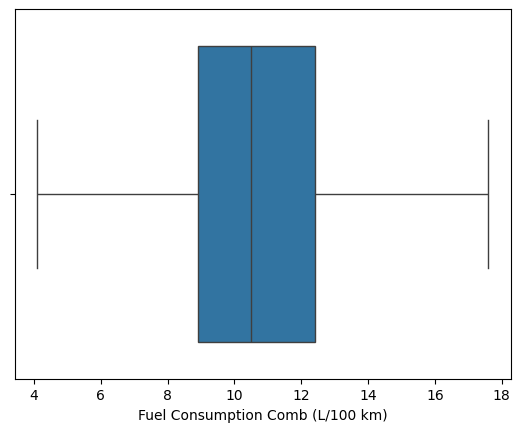

In [241]:
sns.boxplot(x=x_train['Fuel Consumption Comb (L/100 km)'])

<Axes: xlabel='Fuel Consumption Comb (mpg)'>

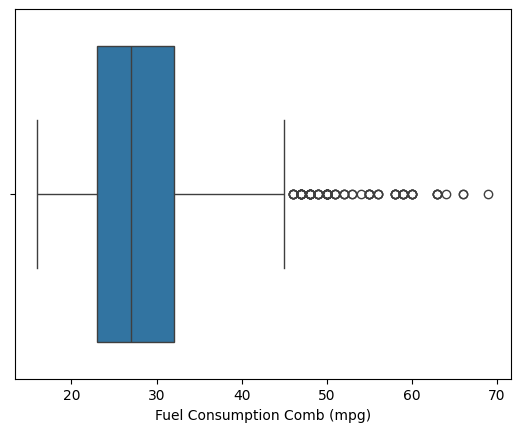

In [242]:
sns.boxplot(x=x_train['Fuel Consumption Comb (mpg)'])

In [243]:
mask = (x_train['Fuel Consumption Comb (mpg)'] < upper_limit_xtrain('Fuel Consumption Comb (mpg)')) & (x_train['Fuel Consumption Comb (mpg)'] > lower_limit_xtrain('Fuel Consumption Comb (mpg)'))

In [244]:
x_train = x_train[mask]
y_train = y_train[mask]

<Axes: xlabel='Fuel Consumption Comb (mpg)'>

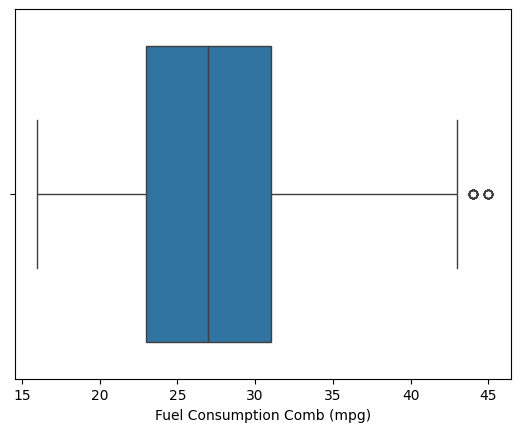

In [245]:
sns.boxplot(x=x_train['Fuel Consumption Comb (mpg)'])

<Axes: xlabel='CO2 Emissions(g/km)'>

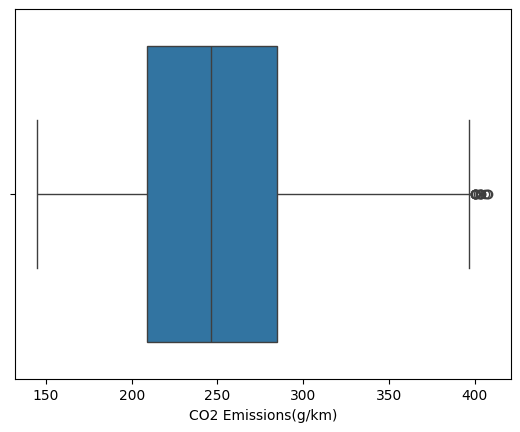

In [246]:
sns.boxplot(x=y_train)

In [247]:
mask = (y_train < upper_limit_ytrain()) & (y_train > lower_limit_ytrain())

In [248]:
x_train = x_train[mask]
y_train = y_train[mask]

<Axes: xlabel='CO2 Emissions(g/km)'>

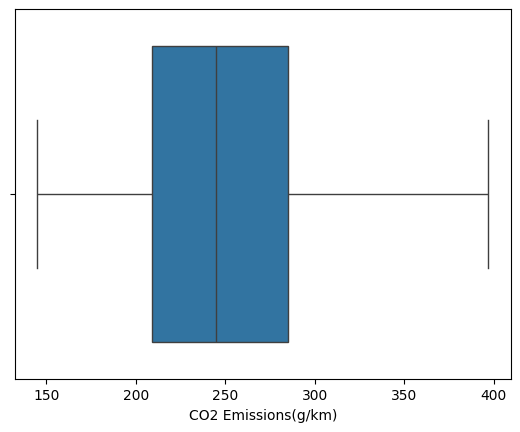

In [249]:
sns.boxplot(x=y_train)

In [250]:
x_train.shape

(4743, 11)

In [251]:
y_train.shape

(4743,)

Outliers were identified and dropped

###Data Skewness

In [252]:
x_train['Fuel Consumption City (L/100 km)'].skew()

np.float64(0.5106434497507281)

/tmp/ipykernel_5026/1612662473.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train['Fuel Consumption City (L/100 km)'])


<Axes: ylabel='Density'>

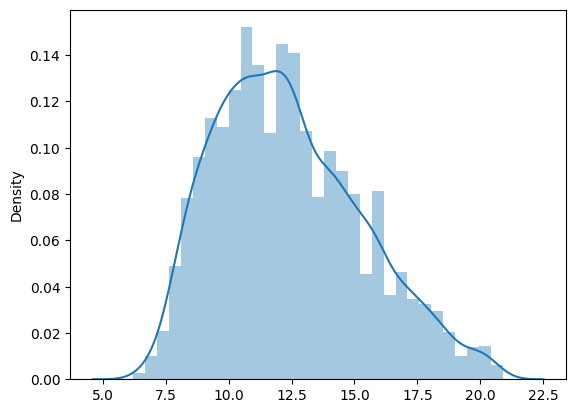

In [253]:
sns.distplot(x=x_train['Fuel Consumption City (L/100 km)'])

In [254]:
x_train['Fuel Consumption Hwy (L/100 km)'].skew()

np.float64(0.5622916040771363)

/tmp/ipykernel_5026/2569645605.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train['Fuel Consumption Hwy (L/100 km)'])


<Axes: ylabel='Density'>

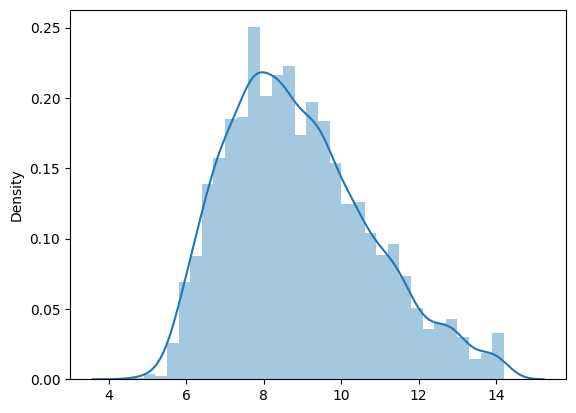

In [255]:
sns.distplot(x=x_train['Fuel Consumption Hwy (L/100 km)'])

In [256]:
x_train['Fuel Consumption Comb (L/100 km)'].skew()

np.float64(0.5096643332259587)

/tmp/ipykernel_5026/2745836742.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train['Fuel Consumption Comb (L/100 km)'])


<Axes: ylabel='Density'>

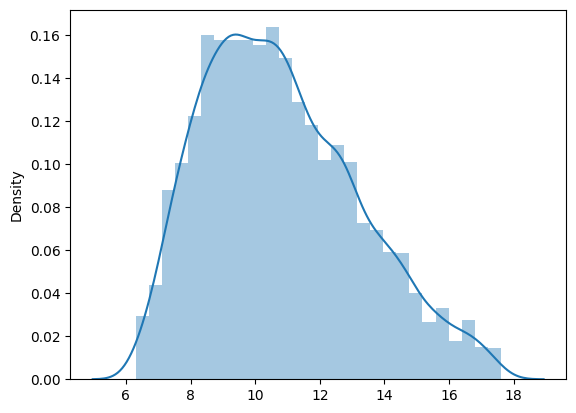

In [257]:
sns.distplot(x=x_train['Fuel Consumption Comb (L/100 km)'])

In [258]:
x_train['Fuel Consumption Comb (mpg)'].skew()

np.float64(0.3846600767713503)

/tmp/ipykernel_5026/4104144145.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=x_train['Fuel Consumption Comb (mpg)'])


<Axes: ylabel='Density'>

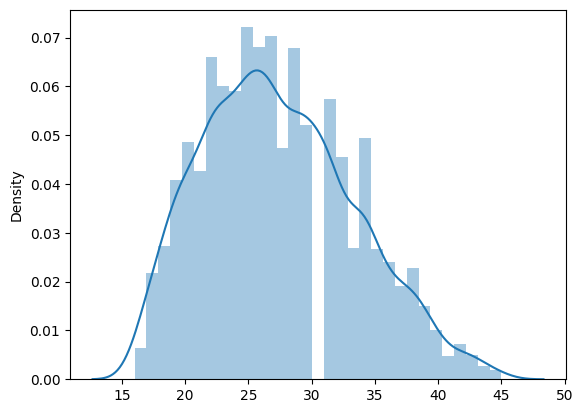

In [259]:
sns.distplot(x=x_train['Fuel Consumption Comb (mpg)'])

Data skewness is under control, no need to handle it

##Feature Engineering

###Features

Categorical Feature - Make, Model, Vehicle Class, Engine Size(L), Cylinders, Transmission, Fuel Type

Numerical Feature - Fuel Consumption City (L/100 km), Fuel Consumption Hwy (L/100 km), Fuel Consumption Comb (L/100 km), Fuel Consumption Comb (mpg)

###Feature 1 - Make

<Axes: xlabel='Make'>

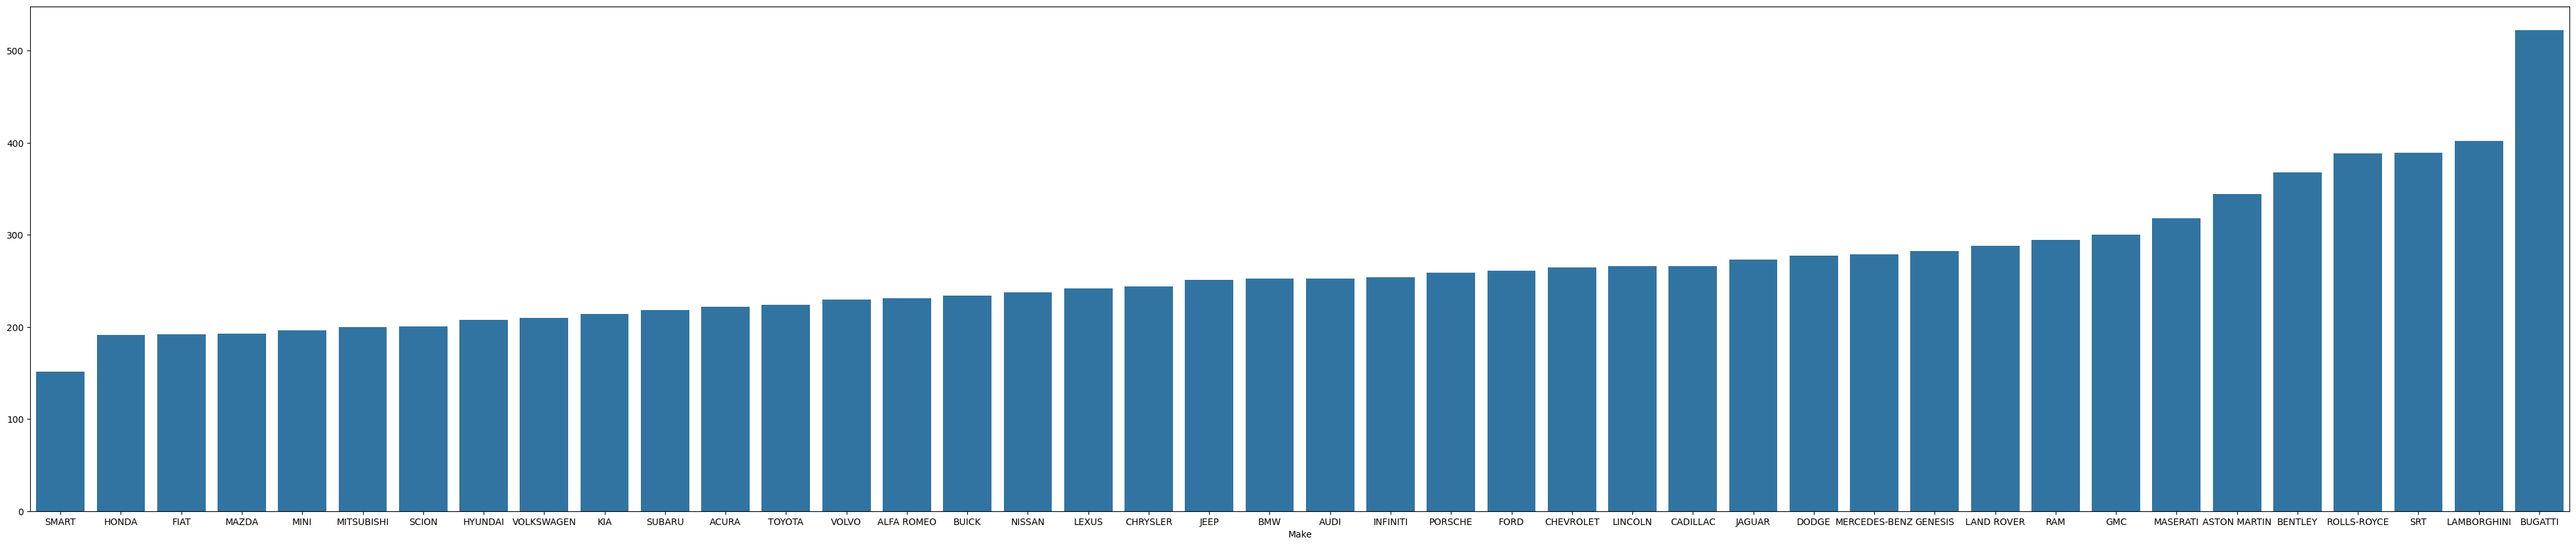

In [260]:
df_make = df.groupby('Make')['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(50,10))
sns.barplot(x=df_make.index,y=df_make.values)

From the above bar chart we can infer different make can influence the CO2 emission

###Feature 2 - Model

<Axes: xlabel='Model'>

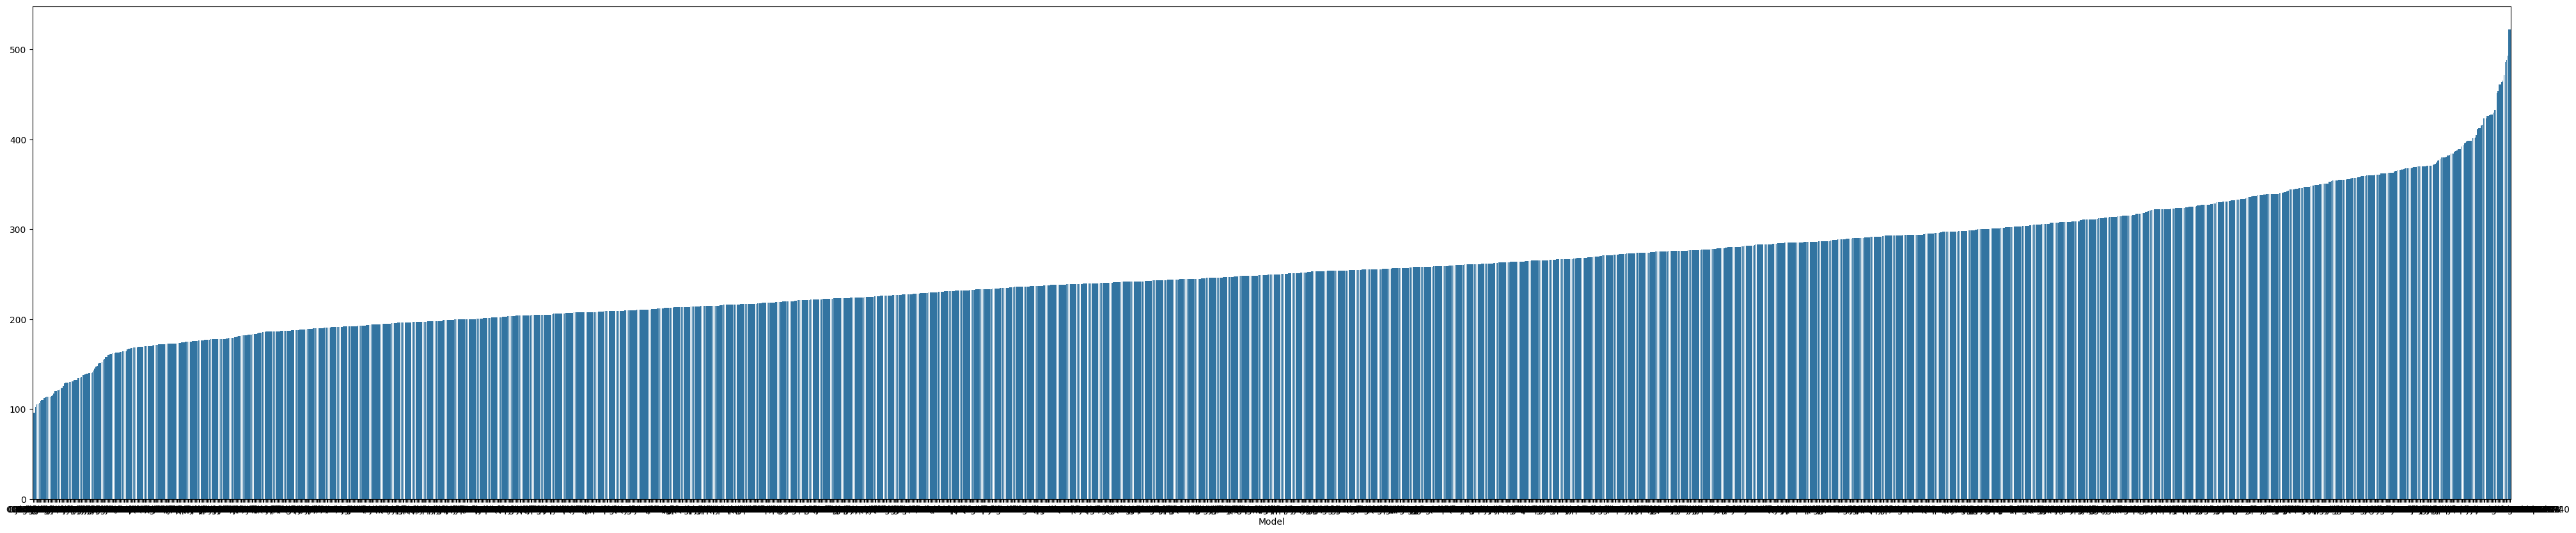

In [261]:
df_model = df.groupby('Model')['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(50,10))
sns.barplot(x=df_model.index,y=df_model.values)

From the above bar chart we can infer different model can influence CO2 emission

###Feature 3 - Vehicle Class

<Axes: xlabel='Vehicle Class'>

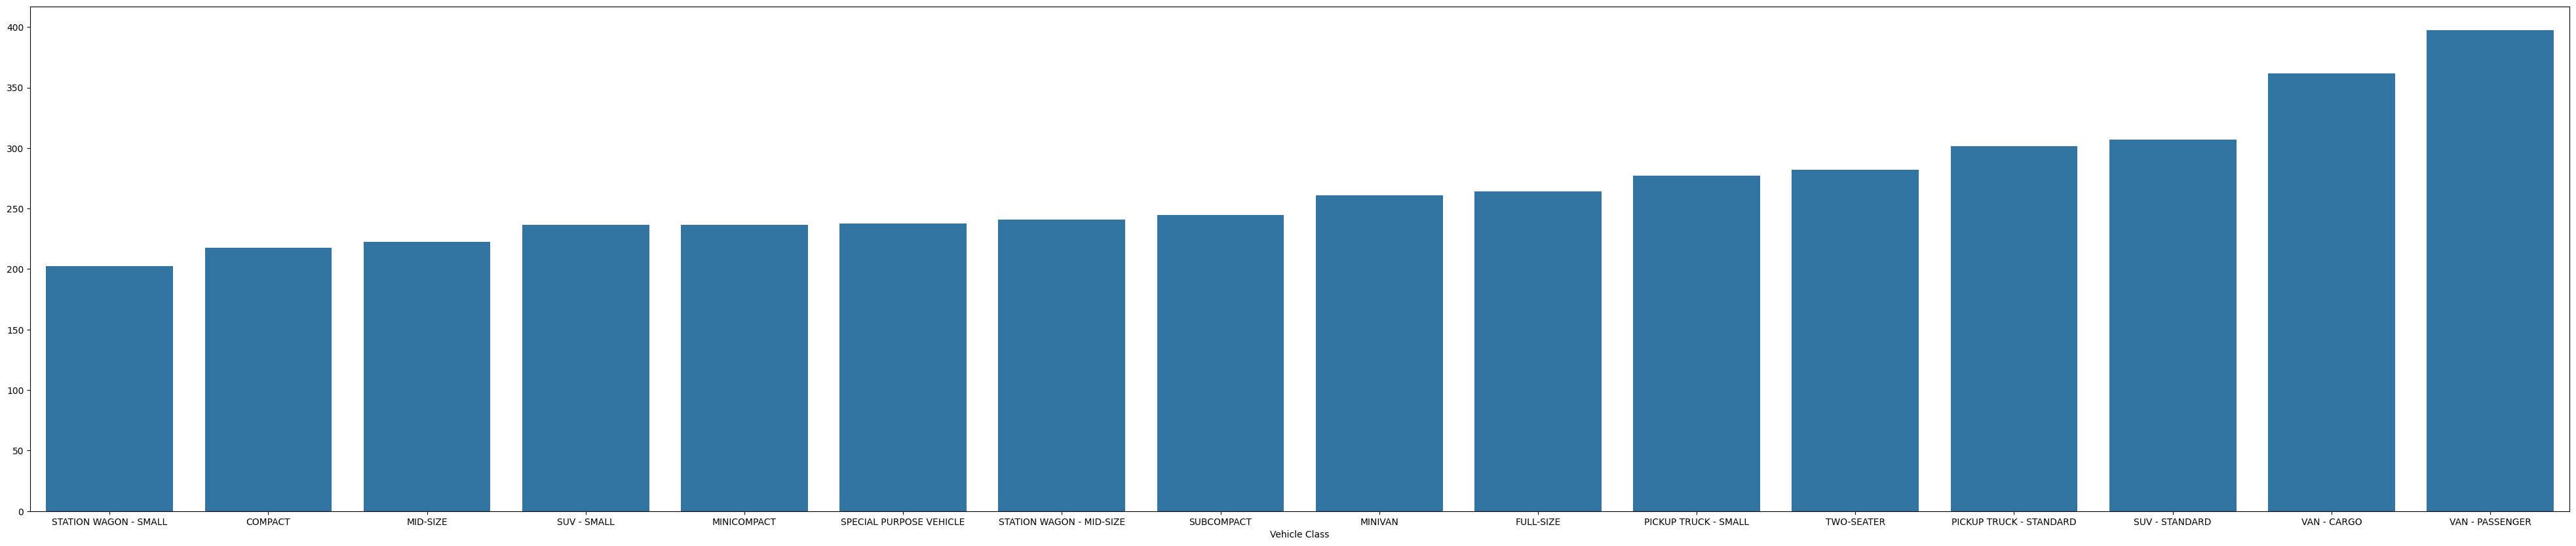

In [262]:
df_model = df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(50,10))
sns.barplot(x=df_model.index,y=df_model.values)

From the above bar chart we can infer different Vehcile Class can influence the CO2 emission

###Feature 4 - Engine Size(L)

<Axes: xlabel='Engine Size(L)'>

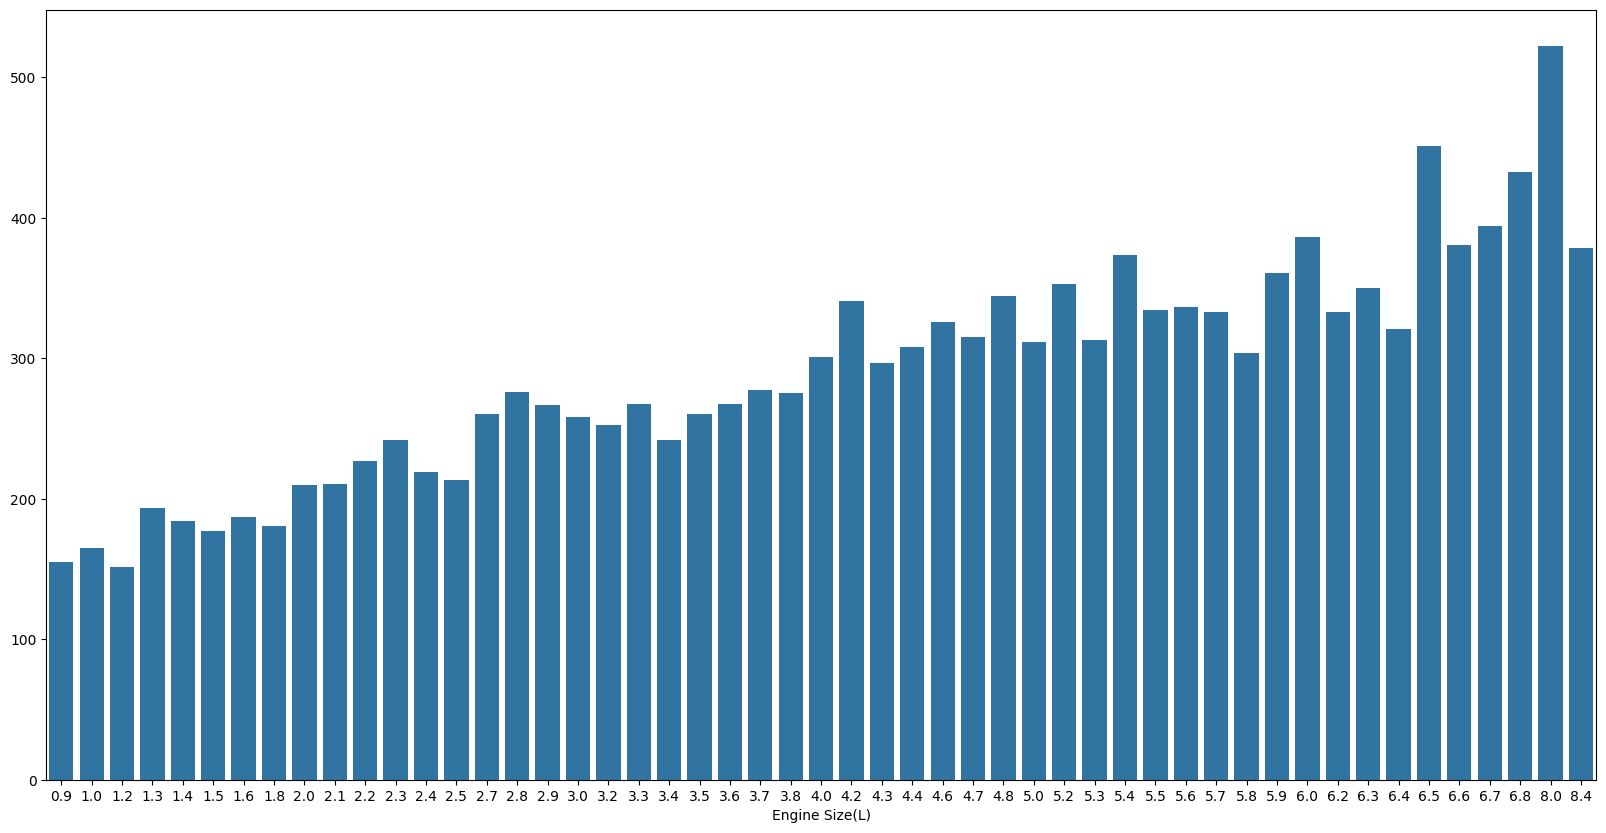

In [263]:
df_model = df.groupby('Engine Size(L)')['CO2 Emissions(g/km)'].mean().sort_values()
plt.figure(figsize=(20,10))
sns.barplot(x=df_model.index,y=df_model.values)

From the above bar chart we can infer different Engine sizes can influence the CO2 emission

### Feature 5 - Cylinders

<Axes: xlabel='Cylinders'>

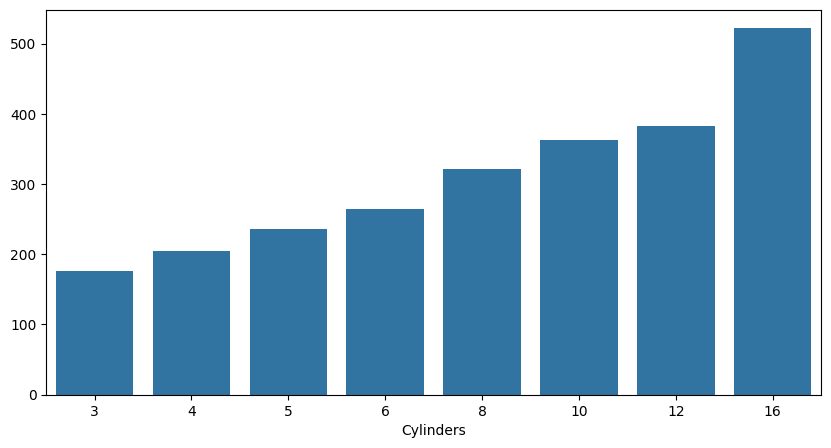

In [264]:
df_cylinders = df.groupby('Cylinders')['CO2 Emissions(g/km)'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=df_cylinders.index,y=df_cylinders.values)

From the above bar chart we can infer influence of the CO2 emission over different number of cylinders

###Feature 6 - Transmission

<Axes: xlabel='Transmission'>

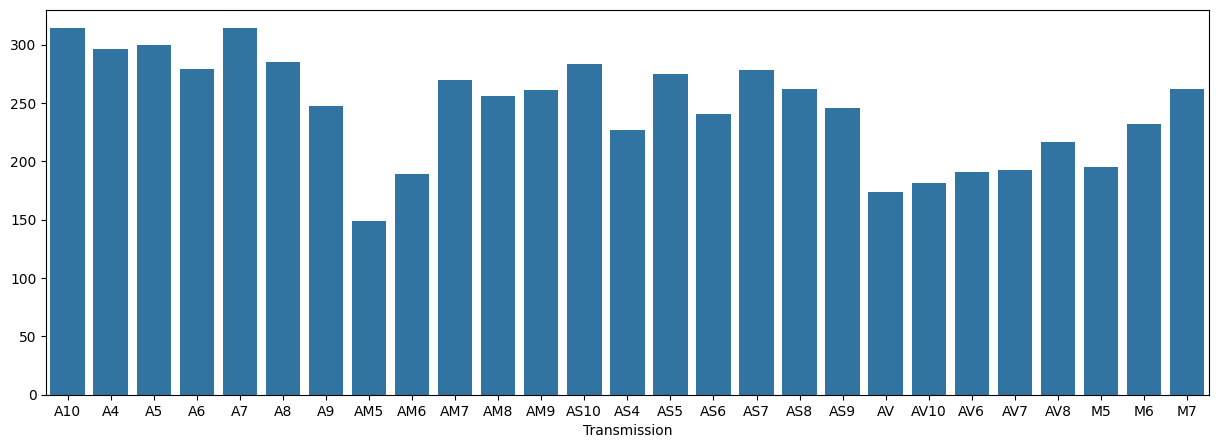

In [265]:
df_cylinders = df.groupby('Transmission')['CO2 Emissions(g/km)'].mean()
plt.figure(figsize=(15,5))
sns.barplot(x=df_cylinders.index,y=df_cylinders.values)

From the above bar chart we can infer different Transmission influence on the CO2 emission

###Feature 7 - Fuel Type

<Axes: xlabel='Fuel Type'>

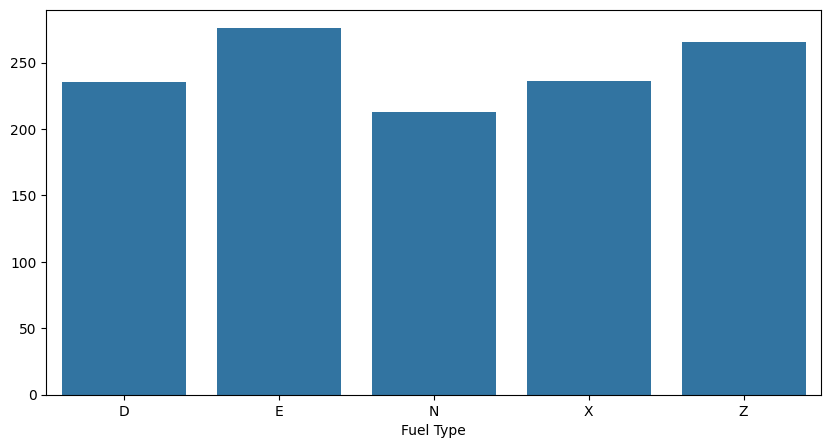

In [266]:
df_cylinders = df.groupby('Fuel Type')['CO2 Emissions(g/km)'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=df_cylinders.index,y=df_cylinders.values)

From the above bar chart we can infer different Fuel Type influence on the CO2 emission

###Feature 8 - Fuel Consumption City (L/100 km)

<Axes: xlabel='Fuel Consumption City (L/100 km)', ylabel='CO2 Emissions(g/km)'>

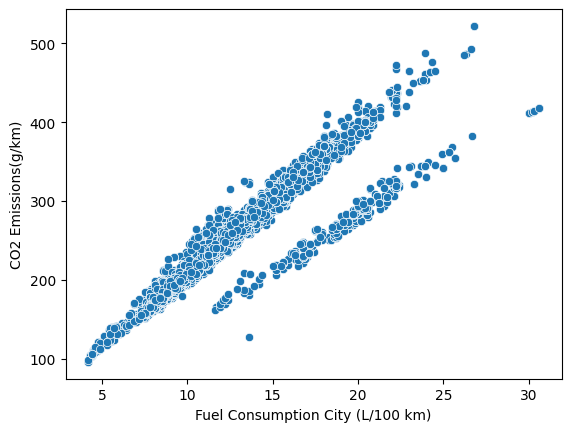

In [267]:
sns.scatterplot(x=df['Fuel Consumption City (L/100 km)'],y=df['CO2 Emissions(g/km)'])

From the above chart we can infer the influence of Fuel Consumption City (L/100 km) in the emission of CO2. Fuel Consumption City (L/100 km) has strong linear relationship with CO2 emission

###Feature 9 - Fuel Consumption Hwy (L/100 km)

<Axes: xlabel='Fuel Consumption Hwy (L/100 km)', ylabel='CO2 Emissions(g/km)'>

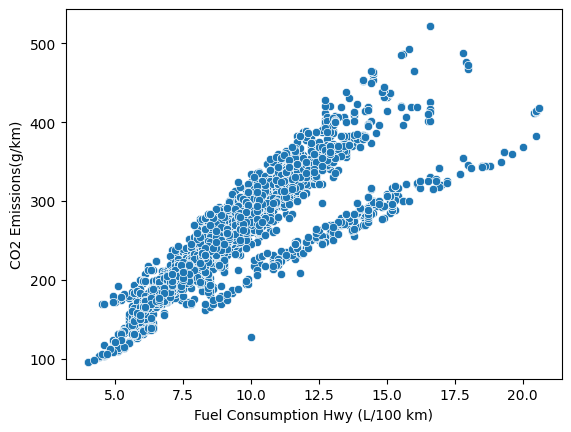

In [268]:
sns.scatterplot(x=df['Fuel Consumption Hwy (L/100 km)'],y=df['CO2 Emissions(g/km)'])

From the above chart we can infer the influence of Fuel Consumption Hwy (L/100 km) in the emission of CO2. Fuel Consumption Hwy (L/100 km) has strong linear relationship with CO2 emission

###Feature 10 - Fuel Consumption Comb (L/100 km)

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='CO2 Emissions(g/km)'>

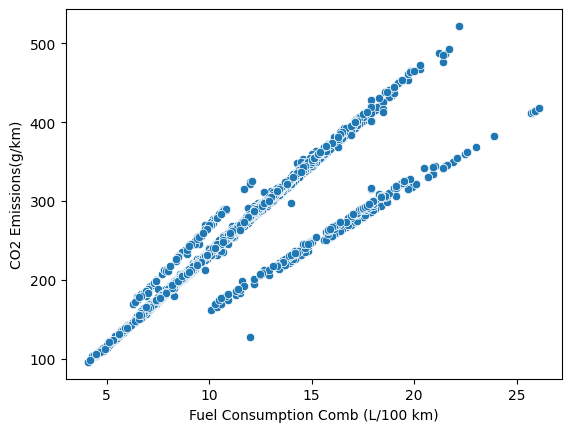

In [269]:
sns.scatterplot(x=df['Fuel Consumption Comb (L/100 km)'],y=df['CO2 Emissions(g/km)'])

From the above chart we can infer the influence of Fuel Consumption Comb (L/100 km) in the emission of CO2. Fuel Consumption Comb (L/100 km) has strong linear relationship with CO2 emission

###Feature 11 - Fuel Consumption Comb (mpg)

<Axes: xlabel='Fuel Consumption Comb (mpg)', ylabel='CO2 Emissions(g/km)'>

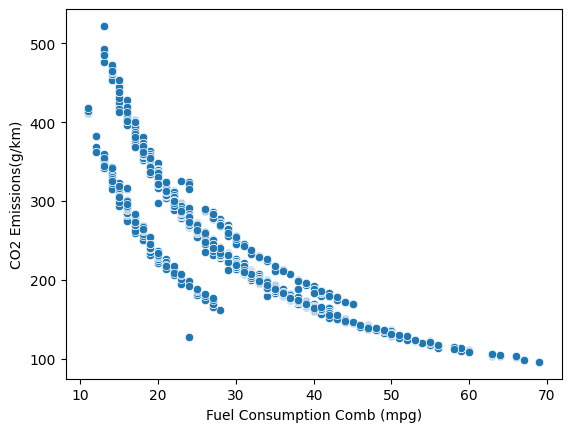

In [270]:
sns.scatterplot(x=df['Fuel Consumption Comb (mpg)'],y=df['CO2 Emissions(g/km)'])

From the above chart we can infer the influence of Fuel Consumption Comb (mpg)  in the emission of CO2. Fuel Consumption Comb (mpg)  has strong negative relationship with CO2 emission

###Correlation Matrix

In [271]:
corr = df[['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)','CO2 Emissions(g/km)']].corr()
corr

,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Fuel Consumption City (L/100 km),1.000000,0.950811,0.994052,-0.927640,0.918756
Fuel Consumption Hwy (L/100 km),0.950811,1.000000,0.978607,-0.891892,0.883424
Fuel Consumption Comb (L/100 km),0.994052,0.978607,1.000000,-0.925801,0.916840
Fuel Consumption Comb (mpg),-0.927640,-0.891892,-0.925801,1.000000,-0.906783
CO2 Emissions(g/km),0.918756,0.883424,0.916840,-0.906783,1.000000


###Heatmap

<Axes: >

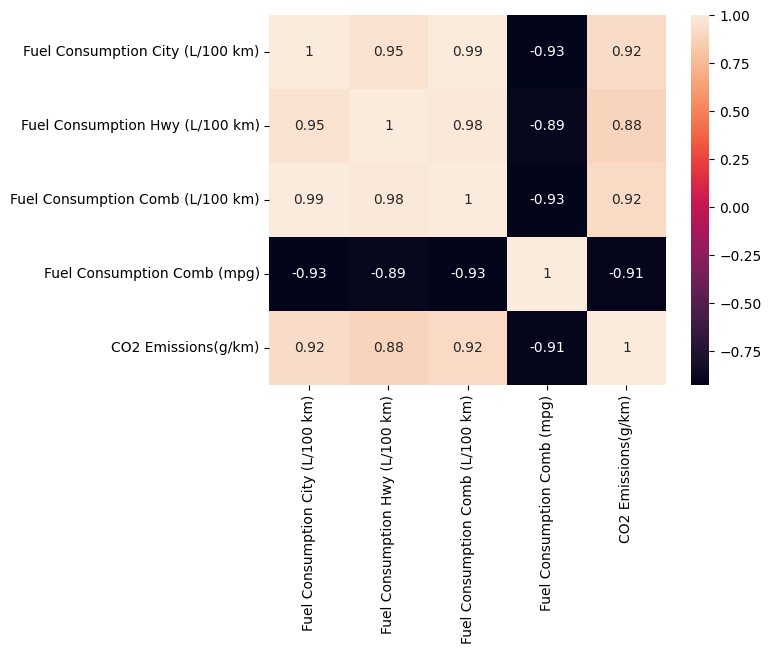

In [272]:
sns.heatmap(corr,annot=True)

###Multicolinearity

In [273]:
x_VIF = x_train[['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)']]
VIF = pd.DataFrame()
VIF['Features'] = x_VIF.columns
VIF['VIF'] = [variance_inflation_factor(x_VIF,i) for i in range(x_VIF.shape[1])]
VIF

,Features,VIF
0,Fuel Consumption City (L/100 km),28396.118516
1,Fuel Consumption Hwy (L/100 km),9788.080354
2,Fuel Consumption Comb (L/100 km),70774.822929


Since the features 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)' posses very high colinearity. Only 'Fuel Consumption Comb (L/100 km)' is used for model generation. Combined fuel composition could cover both fuel composition in city and highway, So the feature is selected for model building

###Feature scaling

In [274]:
x_train['Make'].nunique()

41

In [275]:
x_train['Model'].nunique()

1817

1. Though Make and Model features are influencung CO2 emission, these features are categorical features and unique count of the features are high. Encoding the column will heavily increase the number of columns. So these two features are omitted for model creation

2. Feature 'Fuel Consumption Comb (L/100 km)' and 'Fuel Consumption Comb (mpg)' represents same data in different units. So one among the two is considered for model creation

In [276]:
x_train=x_train[['Vehicle Class','Engine Size(L)','Cylinders','Transmission','Fuel Type','Fuel Consumption Comb (L/100 km)']]

In [277]:
x_test=x_test[['Vehicle Class','Engine Size(L)','Cylinders','Transmission','Fuel Type','Fuel Consumption Comb (L/100 km)']]

In [278]:
x_train.reset_index(inplace=True)
x_train.drop('index',axis=1,inplace=True)
x_test.reset_index(inplace=True)
x_test.drop('index',axis=1,inplace=True)
y_train = y_train.reset_index()
y_train.drop('index',axis=1,inplace=True)
y_test = y_test.reset_index()
y_test.drop('index',axis=1,inplace=True)

In [279]:
preprocessor = ColumnTransformer(transformers=[('encoder',OneHotEncoder(handle_unknown='ignore'),['Vehicle Class','Transmission','Fuel Type']),('standardisation',StandardScaler(),['Engine Size(L)','Cylinders','Fuel Consumption Comb (L/100 km)'])])

In [280]:
preprocessor

ColumnTransformer(transformers=[('encoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Vehicle Class', 'Transmission',
                                  'Fuel Type']),
                                ('standardisation', StandardScaler(),
                                 ['Engine Size(L)', 'Cylinders',
                                  'Fuel Consumption Comb (L/100 km)'])])

Since the numerical features posses strong linear relationship with target variable, Multi variate linear Regression model is used here to predict the CO2 Emission

##Model Building

In [281]:
pipeline = Pipeline([('preprocessing',preprocessor),('Model',LinearRegression())])
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle Class',
                                                   'Transmission',
                                                   'Fuel Type']),
                                                 ('standardisation',
                                                  StandardScaler(),
                                                  ['Engine Size(L)',
                                                   'Cylinders',
                                                   'Fuel Consumption Comb '
                                                   '(L/100 km)'])])),
                ('Model', LinearRegression())])

##Cross validation

In [282]:
cross_val_score(pipeline,x_train,y_train,cv=5,scoring='r2').mean()

np.float64(0.9947984918641464)

In [283]:
abs(cross_val_score(pipeline,x_train,y_train,cv=5,scoring='neg_mean_absolute_error').mean())

np.float64(2.488812131139214)

In [284]:
abs(cross_val_score(pipeline,x_train,y_train,cv=5,scoring='neg_mean_squared_error').mean())

np.float64(14.281383060664563)

In [285]:
abs(cross_val_score(pipeline,x_train,y_train,cv=5,scoring='neg_root_mean_squared_error').mean())

np.float64(3.7657968635942383)

The above results indicate that the model is highly accurate, stable across different data splits, and generalizes well to unseen data.

##Model Training

In [286]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle Class',
                                                   'Transmission',
                                                   'Fuel Type']),
                                                 ('standardisation',
                                                  StandardScaler(),
                                                  ['Engine Size(L)',
                                                   'Cylinders',
                                                   'Fuel Consumption Comb '
                                                   '(L/100 km)'])])),
                ('Model', LinearRegression())])

##Model Evaluation

In [287]:
pipeline.score(x_train,y_train)

0.9952275054659736

In [288]:
pipeline.score(x_test,y_test)

0.9895370183033724

The model achieved an R² score of 0.989 during the testing, indicating excellent predictive performance. This means that approximately 98.9% of the variation in CO₂ emissions is explained by the model, suggesting that the selected features are highly effective in predicting emission levels.

In [289]:
y_pred = pipeline.predict(x_test).ravel()
y_pred

array([232.67751885, 197.27577733, 241.63336327, ..., 192.78009636,
       365.19055244, 186.94910485])

In [290]:
mae = mean_absolute_error(y_test,y_pred)
mae

2.9085574263051632

In [291]:
(mae/df['CO2 Emissions(g/km)'].mean())*100

np.float64(1.1580599840439048)

In [292]:
mean_squared_error(y_test,y_pred)

37.71205998118432

In [293]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

6.141014572624325

In [294]:
(rmse/df['CO2 Emissions(g/km)'].mean())*100

np.float64(2.445082628820877)

##Verifying the normal distribution of residuals

In [295]:
residual = y_test - pipeline.predict(x_test)

/tmp/ipykernel_5026/1858500573.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual)


<Axes: xlabel='Residual', ylabel='Density'>

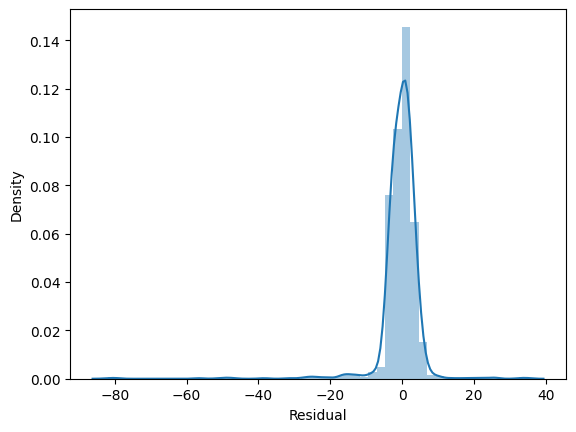

In [296]:
plt.xlabel('Residual')
sns.distplot(residual)

Distribution of residuals is fairly close to normal distribution

##Verifying the Homoscedasticity

In [297]:
residuals = residual.values.ravel()

<Axes: xlabel='Predicted Values', ylabel='Residuals'>

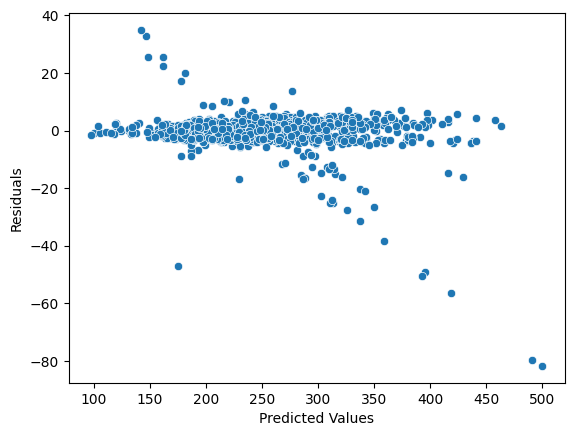

In [298]:
plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

sns.scatterplot(x=y_pred,y=residuals)

The residual plot shows that most residuals are randomly scattered around zero without a strong systematic pattern, which suggests that the linear regression model reasonably satisfies the homoscedasticity assumption. This indicates that the variance of errors remains fairly consistent across different predicted values.

##Inference

In [299]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

coefficients = pipeline.named_steps[
    'Model'
].coef_.flatten()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df

,Feature,Coefficient
0,encoder__Vehicle Class_COMPACT,-0.367776
1,encoder__Vehicle Class_FULL-SIZE,0.080261
2,encoder__Vehicle Class_MID-SIZE,-0.373473
3,encoder__Vehicle Class_MINICOMPACT,-0.568532
4,encoder__Vehicle Class_MINIVAN,-0.969861
5,encoder__Vehicle Class_PICKUP TRUCK - SMALL,2.395958
6,encoder__Vehicle Class_PICKUP TRUCK - STANDARD,0.413059
7,encoder__Vehicle Class_SPECIAL PURPOSE VEHICLE,0.873718
8,encoder__Vehicle Class_STATION WAGON - MID-SIZE,-0.214135
9,encoder__Vehicle Class_STATION WAGON - SMALL,-0.749303


1. Usage of fuel Type D, X, Z leads to more CO2 emission and usage of fuel E and N decreases CO2 emission.

2. Fuel consumption is directly propotional to CO2 Emission. Vehicles with high fuel consumption is likely to increase CO2 emission